#### Loading images to PyTorch
Define transformations:
- Parse to tensor
- Resize to 128x128

Create dataset passing:
- Path to data
- Predefined transformations


In [3]:
!pip install torchvision
!pip install pytorch

  Using cached sympy-1.14.0-py3-none-any.whl.metadata (12 kB)
  Using cached networkx-3.6.1-py3-none-any.whl.metadata (6.8 kB)
  Using cached mpmath-1.3.0-py3-none-any.whl.metadata (8.6 kB)
Using cached networkx-3.6.1-py3-none-any.whl (2.1 MB)
Using cached sympy-1.14.0-py3-none-any.whl (6.3 MB)
Using cached mpmath-1.3.0-py3-none-any.whl (536 kB)

   ---------------------------------------- 0/3 [mpmath]
   ---------------------------------------- 0/3 [mpmath]
   ---------------------------------------- 0/3 [mpmath]
   ---------------------------------------- 0/3 [mpmath]
   ---------------------------------------- 0/3 [mpmath]
   ---------------------------------------- 0/3 [mpmath]
   ---------------------------------------- 0/3 [mpmath]
   ---------------------------------------- 0/3 [mpmath]
   ---------------------------------------- 0/3 [mpmath]
   ---------------------------------------- 0/3 [mpmath]
   ---------------------------------------- 0/3 [mpmath]
   ---------------------

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
llama-index-core 0.14.13 requires aiohttp<4,>=3.8.6, which is not installed.
llama-index-core 0.14.13 requires sqlalchemy[asyncio]>=1.4.49, which is not installed.
llama-index-core 0.14.13 requires wrapt, which is not installed.
llama-index-readers-file 0.5.6 requires beautifulsoup4<5,>=4.12.3, which is not installed.
llama-index-readers-file 0.5.6 requires defusedxml>=0.7.1, which is not installed.

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


  Using cached pytorch-1.0.2.tar.gz (689 bytes)
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
Failed to build pytorch


  error: subprocess-exited-with-error
  
  × Building wheel for pytorch (pyproject.toml) did not run successfully.
  │ exit code: 1
  ╰─> [37 lines of output]
      Traceback (most recent call last):
        File "C:\Users\USER\AppData\Local\Programs\Python\Python313\Lib\site-packages\pip\_vendor\pyproject_hooks\_in_process\_in_process.py", line 389, in <module>
          main()
          ~~~~^^
        File "C:\Users\USER\AppData\Local\Programs\Python\Python313\Lib\site-packages\pip\_vendor\pyproject_hooks\_in_process\_in_process.py", line 373, in main
          json_out["return_val"] = hook(**hook_input["kwargs"])
                                   ~~~~^^^^^^^^^^^^^^^^^^^^^^^^
        File "C:\Users\USER\AppData\Local\Programs\Python\Python313\Lib\site-packages\pip\_vendor\pyproject_hooks\_in_process\_in_process.py", line 280, in build_wheel
          return _build_backend().build_wheel(
                 ~~~~~~~~~~~~~~~~~~~~~~~~~~~~^
              wheel_directory, config_settings, me

In [4]:
from torchvision.datasets import ImageFolder
from torchvision import transforms

train_transforms = transforms.Compose([
    transforms.ToTensor(),
    transforms.Resize((128, 128)),
])

dataset_train = ImageFolder(
    "clouds/clouds_train",
    transform=train_transforms,
)

#### Displaying images

In [5]:
from torch.utils.data import DataLoader

dataloader_train = DataLoader(
    dataset_train,
    shuffle = True,
    batch_size = 1,
    )

image, label = next(iter(dataloader_train))
print(image.shape)

torch.Size([1, 3, 128, 128])


In [6]:
image = image.squeeze().permute(1, 2, 0)
print(image.shape)

torch.Size([128, 128, 3])


In [7]:
pip install imshow

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


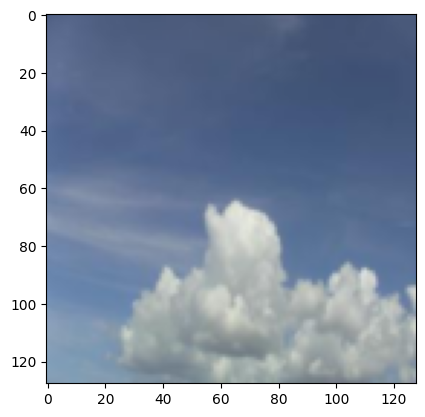

In [8]:
import matplotlib.pyplot as plt
plt.imshow(image)
plt.show()

### Data augmentation

Data augmentation: Generating more data by applying random transformations to original images

- Increase the size and diversity of the training set
- Improve model robustness
- Reduce overfitting

In [9]:
# Data augmentation

train_transforms = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(45),
    transforms.ToTensor(),
    transforms.Resize((128, 128)),
])

dataset_train = ImageFolder(
    "clouds/clouds_train",
    transform=train_transforms,
)

In [ ]:
# Compose transformations
train_transforms =transforms.Compose([
    transforms.ToTensor(),
    transforms.Resize((128, 128)),
])

# Create Dataset using ImageFolder
dataset_train = ImageFolder(
    'clouds_train',
    transform=train_transforms,
)

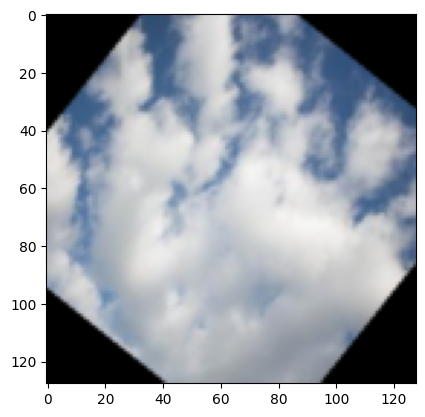

In [10]:
train_transforms = transforms.Compose([
    # Add horizontal flip and rotation
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(45),
    transforms.ToTensor(),
    transforms.Resize((128, 128)),
])

dataset_train = ImageFolder(
  "clouds/clouds_train",
  transform=train_transforms,
)

dataloader_train = DataLoader(
  dataset_train, shuffle=True, batch_size=1
)

image, label = next(iter(dataloader_train))
# Reshape the image tensor
image = image.squeeze().permute(1, 2, 0) 
# Display the image
plt.imshow(image)
plt.show()

# Convolutional Neural Networks

Why not use linear layers?
- Linear layers:
  - Slow training
  - Overfitting
  - Don't recognize spatial patterns
- A Better alternative: Convolutional layers

#### Convolutional layer
- Slide filter(s) of parameters over the input 
- At each position, perform convolution
- Resulting feature map:
    - Preservers spatial patterns from input 
    - Uses fewer parameters than linear layer
- One filter = one feature map
- Apply activations to feature maps
- All feature maps combined form the output
- `nn.Conv2d(3, 32, kernel_size=3)`

##### Convolution
1. Compute dot product of input patch and filter
    - Top-left field: 2 x 1 = 2
2. Sum the result


#### Zero-padding
- Add a frames of zeros to convolutional layer's input
`nn.Conv2d(3, 32, kernel_size=3, padding=1)`
- Maintains spatial dimensions of the input and output tensors
- Ensures border pixels are treated equally to others

#### Max Pooling
- Slide no-overlapping window over input
- At each position, retain only the maximum value
- Used after convolutional layers to reduce spartial dimensions
- `nn.MaxPool2d(kernel_size=2)`


#### Convolutional Neural Network
- `feature_extractor`: (convolution, activation, pooling), repeated twice and flattened
- `classifier`: single linear layer
- `forward()`: pass input image through feature extractor and classifier


In [ ]:
class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.feature_extractor = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ELU(),
            nn.MaxPool2d(kernel_size=2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ELU(),
            nn.MaxPool2d(kernel_size=2),
            nn.Flatten(),
        )
        self.classifier = nn.Linear(64*16*16, num_classes)

    def forward(self, x):
        x = self.feature_extractor(x)
        x = self.classifier(x)
        return x

#### Feature extractor output size

In [ ]:
self.feature_extractor = nn.Sequential(
    nn.Conv2d(3, 32, kernel_size=3, padding=1),
    nn.ELU(),
    nn.MaxPool2d(kernel_size=2),
    nn.Conv2d(32, 64, kernel_size=3, padding=1),
    nn.ELU(),
    nn.MaxPool2d(kernel_size=2),
    nn.Flatten(),
)

self.classifier = nn.Linear(64*16*16, num_classes)

##### Exercises:

In [ ]:
class Net(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        # Define feature extractor
        self.feature_extractor = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ELU(),
            nn.MaxPool2d(kernel_size=2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ELU(),
            nn.MaxPool2d(kernel_size=2),
            nn.Flatten(),
        )
        # Define classifier
        self.classifier = nn.Linear(64*16*16, num_classes)
    
    def forward(self, x):  
        # Pass input through feature extractor and classifier
        x = self.feature_extractor(x)
        x = self.classifier(x)
        return x

##### Training image classifiers

What should not be augmented
- Augmentations can impact the label 
- Whether this is confusing depends on the task
- Always choose augmentations with the data and task in mind!

#### Augmentations of cloud classification

- Random rotation: expose model to different angles of cloud formations
- Horizontal flip: simulate different viewpoints of the sky
- Auto contrast adjustment: Simulate different lighting conditions

#### Cross-Entropy loss
- Binary classification: binary cross-entropy (BCE) loss
- Multi-class classification: cross-entropy loss
- `criterion = nn.CrossEntropyLoss()`

##### Image classifier training loop

In [ ]:
net = Net(num_classes=7)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(net.parameters(), lr=0.001)

for epoch in range(10):
    for images, labels in dataloader_train:
        optimizer.zero_grad()
        outputs = net(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()